## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting? 
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Geethan Sundaram

**Date:** 9/30/2026

In [1]:
import textwrap

# Your Phase 1 solution to the problem goes here.
print("-- Question 1.1 --")
question_1_1 = "The difference between regression and classification is that regression predicts numerical values with continuous ranges, while classification predicts discrete labels or categories. An example of a regression problem is predicting the price of a house based on its features, while an example of a classification problem is predicting whether an email is spam or not."
print(textwrap.fill(question_1_1, width=80))
print("\n")
print("-- Question 1.2 --")
question_1_2 = "A confusion table compares a model's predicted labels against the actual labels, which helps evaluate the model's performance by showing us true positives (TP), true negatives (TN), false positives (FP), and false negatives (FN)."
print(textwrap.fill(question_1_2, width=80))
print("\n")
print("-- Question 1.3 --")
question_1_3 = "The SSE or Sum of Squared Errors measures the total deviation of the predicted values from the actual values in a regression model. It is calculated as the sum of the squares of the differences between the predicted and actual values, or SSE = Sigma(y_i - y_hat_i)^2."
print(textwrap.fill(question_1_3, width=80))
print("\n")
print("-- Question 1.4 --")
question_1_4 = "Overfitting happens when a model learns the training data too well, including noise and outliers, which makes it perform poorly on unseen data. Underfitting occurs when a model is trained too simply and doesn't capture the underlying patterns in the data, which leads to it performing poorly on both training and unseen data."
print(textwrap.fill(question_1_4, width=80))
print("\n")
print("-- Question 1.5 --")
question_1_5 = "If we used data solely for training, then we won't have a good idea of how the model works with new data. For example, you cannot detect overfitting or underfitting properly without a separate validation or test set. This is why we split our data into training and testing sets. We use just the training data to train the model then we have testing data to see if the model performs well on unseen data. This helps us avoid overfitting and underfitting. Choosing k for kNN by evaluating the accuracy or SSE on the test set helps us find the optimal value of k that minimizes the error and provides the best performance. Different values of k can lead to different results, so it's important to choose the right one by testing different values and selecting the one that performs best on the test set."
print(textwrap.fill(question_1_5, width=80))
print("\n")
print("-- Question 1.6 --")
question_1_6 = "A classification model can report a class label as a prediction or a probability distribution over all possible classes. A single class label prediction is very simple to interpret and very useful when a single decision must be made, but it tells us nothing about the model's confidence in that prediction. A probability distribution gives us more information about the model's confidence in each class label, which is very useful for decision-making and understanding the model's behavior. But it can be more complex to interpret, especially when there are many classes."
print(textwrap.fill(question_1_6, width=80))

-- Question 1.1 --
The difference between regression and classification is that regression predicts
numerical values with continuous ranges, while classification predicts discrete
labels or categories. An example of a regression problem is predicting the price
of a house based on its features, while an example of a classification problem
is predicting whether an email is spam or not.


-- Question 1.2 --
A confusion table compares a model's predicted labels against the actual labels,
which helps evaluate the model's performance by showing us true positives (TP),
true negatives (TN), false positives (FP), and false negatives (FN).


-- Question 1.3 --
The SSE or Sum of Squared Errors measures the total deviation of the predicted
values from the actual values in a regression model. It is calculated as the sum
of the squares of the differences between the predicted and actual values, or
SSE = Sigma(y_i - y_hat_i)^2.


-- Question 1.4 --
Overfitting happens when a model learns the training

-- Question 2.1 --


,voltage,height,soil,mine_type
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1


Shape: (338, 4)

Data types:
voltage      float64
height       float64
soil         float64
mine_type      int64
dtype: object

Missing values:
voltage      0
height       0
soil         0
mine_type    0
dtype: int64

Mine type counts:
mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64

Mine type proportions:
mine_type
1    0.210059
2    0.207101
3    0.195266
4    0.195266
5    0.192308
Name: proportion, dtype: float64

Feature summary:


,voltage,height,soil
count,338.000000,338.000000,338.000000
mean,0.430634,0.508876,0.503550
std,0.195819,0.306043,0.344244
min,0.197734,0.000000,0.000000
25%,0.309737,0.272727,0.200000
50%,0.359516,0.545455,0.600000
75%,0.482628,0.727273,0.800000
max,0.999999,1.000000,1.000000



Average feature values by mine type:


,voltage,height,soil
mine_type,,,
1,0.296463,0.495519,0.492958
2,0.721123,0.487013,0.508571
3,0.402408,0.527548,0.496970
4,0.345365,0.506887,0.503030
5,0.379598,0.530070,0.516923


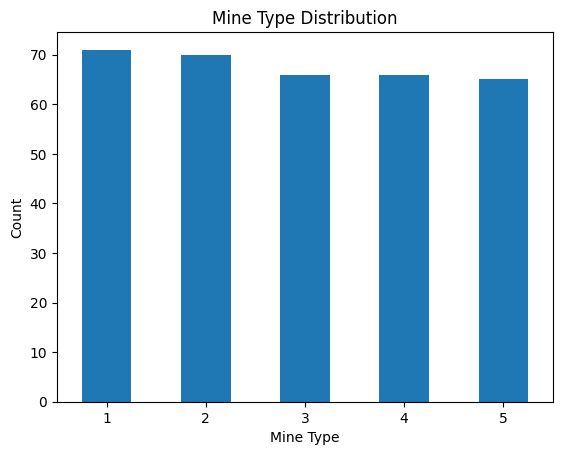

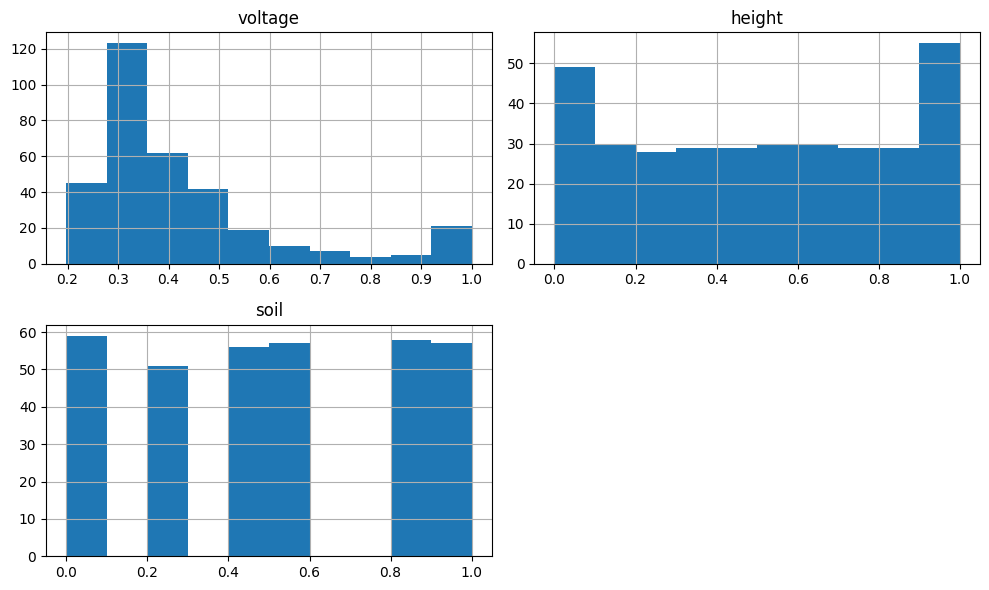

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("-- Question 2.1 --")

import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv("data/land_mines.csv")

# Look at the first few rows
display(df.head())

# Basic information
print("Shape:", df.shape)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

# Target variable counts
print("\nMine type counts:")
print(df["mine_type"].value_counts().sort_index())

print("\nMine type proportions:")
print(df["mine_type"].value_counts(normalize=True).sort_index())

# Summary stats for the features
print("\nFeature summary:")
display(df[["voltage", "height", "soil"]].describe())

# Average feature values by mine type
print("\nAverage feature values by mine type:")
display(
    df.groupby("mine_type")[["voltage", "height", "soil"]].mean()
)

# Plot mine type counts
df["mine_type"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Mine Type")
plt.ylabel("Count")
plt.title("Mine Type Distribution")
plt.xticks(rotation=0)
plt.show()

# Histograms for the features
df[["voltage", "height", "soil"]].hist(figsize=(10, 6))

plt.tight_layout()
plt.show()

In [3]:
from sklearn.model_selection import train_test_split

print("-- Question 2.2 --")

from sklearn.model_selection import train_test_split

# Predictor variables
X = df[["voltage", "height", "soil"]]

# Target variable
y = df["mine_type"]

# Split 50/50
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.5,
    random_state=42,
    stratify=y
)

print("Training set size:", len(X_train))
print("Test set size:", len(X_test))

print("\nTraining set class counts:")
print(y_train.value_counts().sort_index())

print("\nTest set class counts:")
print(y_test.value_counts().sort_index())

-- Question 2.2 --
Training set size: 169
Test set size: 169

Training set class counts:
mine_type
1    35
2    35
3    33
4    33
5    33
Name: count, dtype: int64

Test set class counts:
mine_type
1    36
2    35
3    33
4    33
5    32
Name: count, dtype: int64


-- Question 2.3 --
Best k: 1
Best accuracy: 0.5088757396449705


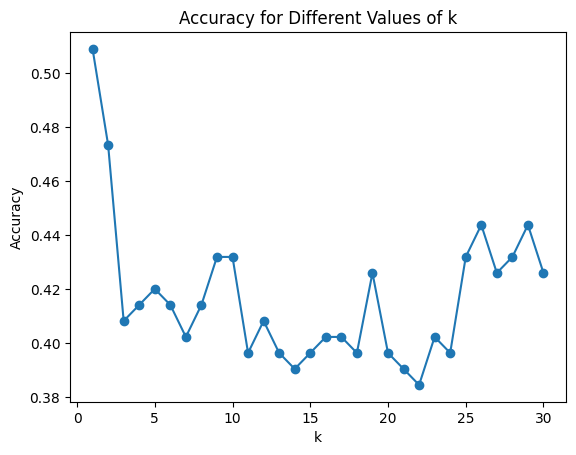

I selected k by evaluating the accuracy of the kNN classifier on the test set
for different values of k (from 1 to 30). I calculated the accuracy for each k
and then identified the value of k with the highest accuracy. With this process,
I ensure that I select a k that generalizes the best to unseen data.


In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

print("-- Question 2.3 --")

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Standardize the features because k-NN uses distance
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Try different values of k
accuracies = []

for k in range(1, 31):
    model = KNeighborsClassifier(n_neighbors=k)

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)

    accuracies.append(accuracy)

# Find the best k
best_k = accuracies.index(max(accuracies)) + 1

print("Best k:", best_k)
print("Best accuracy:", max(accuracies))

# Plot accuracy for each k
plt.plot(range(1, 31), accuracies, marker="o")

plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("Accuracy for Different Values of k")

plt.show()

text = "I selected k by evaluating the accuracy of the kNN classifier on the test set for different values of k (from 1 to 30). I calculated the accuracy for each k and then identified the value of k with the highest accuracy. With this process, I ensure that I select a k that generalizes the best to unseen data."
print(textwrap.fill(text, width=80))

-- Question 2.4 --
Optimal k: 1
Overall accuracy: 50.89%

Confusion Matrix:


,Predicted 1,Predicted 2,Predicted 3,Predicted 4,Predicted 5
Actual 1,22,0,3,3,8
Actual 2,0,32,0,3,0
Actual 3,7,0,10,9,7
Actual 4,6,5,4,13,5
Actual 5,6,0,10,7,9


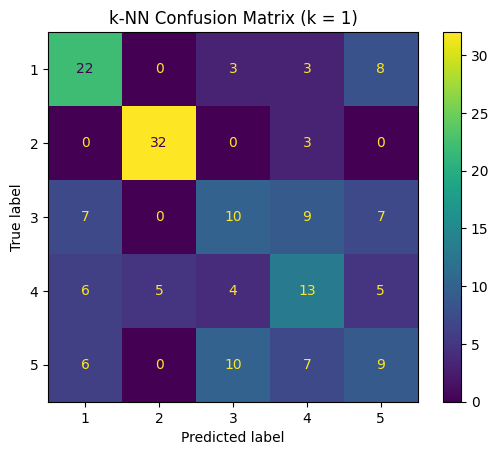


Classification Report:
              precision    recall  f1-score   support

           1       0.54      0.61      0.57        36
           2       0.86      0.91      0.89        35
           3       0.37      0.30      0.33        33
           4       0.37      0.39      0.38        33
           5       0.31      0.28      0.30        32

    accuracy                           0.51       169
   macro avg       0.49      0.50      0.49       169
weighted avg       0.50      0.51      0.50       169


Accuracy by Mine Type:
Mine Type 1: 22/36 = 61.11%
Mine Type 2: 32/35 = 91.43%
Mine Type 3: 10/33 = 30.30%
Mine Type 4: 13/33 = 39.39%
Mine Type 5: 9/32 = 28.12%


The optimal model used k = 1 and achieved an overall accuracy of 50.89% on the
test set. The confusion matrix shows that performance varied a lot across the 5
mine types. Mine Type 2 was classified the most accuractely with 32/35
observations being correct, which translates to a 91.43% accuracy. Mine Type 1
was also not 

In [5]:
print("-- Question 2.4 --")

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# Fit the final model using the best k
knn = KNeighborsClassifier(n_neighbors=best_k)

knn.fit(X_train_scaled, y_train)

# Make predictions
y_pred = knn.predict(X_test_scaled)

# Overall accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Optimal k:", best_k)
print("Overall accuracy:", f"{accuracy:.2%}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=[
        "Actual 1",
        "Actual 2",
        "Actual 3",
        "Actual 4",
        "Actual 5"
    ],
    columns=[
        "Predicted 1",
        "Predicted 2",
        "Predicted 3",
        "Predicted 4",
        "Predicted 5"
    ]
)

print("\nConfusion Matrix:")
display(cm_df)

# Plot confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[1, 2, 3, 4, 5]
).plot()

plt.title(f"k-NN Confusion Matrix (k = {best_k})")
plt.show()

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Accuracy for ech mine type
print("\nAccuracy by Mine Type:")

for i in range(5):
    correct = cm[i, i]
    total = cm[i].sum()

    print(
        f"Mine Type {i + 1}: "
        f"{correct}/{total} = {correct / total:.2%}"
    )
print("\n")
text = "The optimal model used k = 1 and achieved an overall accuracy of 50.89% on the test set. The confusion matrix shows that performance varied a lot across the 5 mine types. Mine Type 2 was classified the most accuractely with 32/35 observations being correct, which translates to a 91.43% accuracy. Mine Type 1 was also not terrible with 22/36 correct classifications, being 61.11% accurate. Mine Types 3, 4, and 5 were classified correctly with 10/33 observations (30.0%), 13/33 observations (39.39%), and 9/32 observations (28.12%) respectively. There were also recurring classification errors, with Mine Type 5 being classified as Mine Type 3 10 times, Mine Type 3 as Mine Type 4 9 times, and Mine Type 1 as Mine Type 5 8 times. This showed that the model was really good at classifying Mine Type 2, but it struggled substantially on the other mine types. The accuracy of 50.89% does not completely describe this much better classification on Mine Type 2."
print(textwrap.fill(text, width=80))

In [6]:
print("-- Question 2.5 --")

# Get predicted probs
probabilities = knn.predict_proba(X_test_scaled)

# Create a small results table
results = pd.DataFrame({
    "actual": y_test.values,
    "predicted": y_pred,
    "confidence": probabilities.max(axis=1)
})

display(results.head(10))

# Look at some incorrect predictions
print("Incorrect predictions:")
display(
    results[
        results["actual"] != results["predicted"]
    ].head(10)
)

test = "I would not recommend using this model as the only mine type identifying method. Even though the model does correctly identify certain mine types very well, its overall accuracy is only slightly over 1/2, and we see that it makes immense mistakes with Mine Types 3-5. I recommend to use this model as an additional source of information rather than the final decision maker. It may help to look at the model's predicted probabilities or confidence rather than solely just a single predicted class. If the model as low confidence or predeicts a mine type that is often confused with another type, then more testing may be necessary. It's important with working with such a safety-critical issue such as land mines. An incorrect classification could lead to serious consequences. Therefore, this model may be useful for supporting a decision but should not take the primary role for making judgements or safety procedures."
print(textwrap.fill(test, width=80))

-- Question 2.5 --


,actual,predicted,confidence
0,3,1,1.0
1,1,4,1.0
2,4,4,1.0
3,4,1,1.0
4,3,3,1.0
5,3,3,1.0
6,4,3,1.0
7,4,1,1.0
8,2,4,1.0
9,4,2,1.0


Incorrect predictions:


,actual,predicted,confidence
0,3,1,1.0
1,1,4,1.0
3,4,1,1.0
6,4,3,1.0
7,4,1,1.0
8,2,4,1.0
9,4,2,1.0
13,3,4,1.0
14,5,4,1.0
17,5,4,1.0


I would not recommend using this model as the only mine type identifying method.
Even though the model does correctly identify certain mine types very well, its
overall accuracy is only slightly over 1/2, and we see that it makes immense
mistakes with Mine Types 3-5. I recommend to use this model as an additional
source of information rather than the final decision maker. It may help to look
at the model's predicted probabilities or confidence rather than solely just a
single predicted class. If the model as low confidence or predeicts a mine type
that is often confused with another type, then more testing may be necessary.
It's important with working with such a safety-critical issue such as land
mines. An incorrect classification could lead to serious consequences.
Therefore, this model may be useful for supporting a decision but should not
take the primary role for making judgements or safety procedures.


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [7]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]